In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import Counter
import random
import numpy as np
import math
from pathlib import Path

In [2]:
# -----------------------------
# 1. Sample corpus
# -----------------------------
!python prep_fairytales.py --indir ./raw_fairytales --outdir corpus --lower --dedup

Loaded raw_fairytales\7439-h.htm
{
  "stories": 1,
  "tokens": 61062,
  "vocab": 5640,
  "removed_non_english": 0,
  "generated_at": "2026-02-19T13:58:41.152266Z"
}
✔ Wrote 1 stories to corpus\clean


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Tânia\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
c:\Users\Tânia\Work\word2vec\prep_fairytales.py:224: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "generated_at": datetime.utcnow().isoformat() + "Z",


In [3]:
def iter_tokens(tokens_path: Path):
    with tokens_path.open("r", encoding="utf-8") as f:
        for line in f:
            yield line.strip().split()

tokens_path = Path('.\\corpus\\clean\\corpus.txt')
tokenized_corpus = list(iter_tokens(tokens_path))

In [4]:
# 1. Preprocessing with Min-Count Filtering
def prepare_data(tokenized_corpus, min_count=5):
    # Count frequencies
    word_counts = Counter([word for sentence in tokenized_corpus for word in sentence])
    # Filter vocab
    vocab = {word: count for word, count in word_counts.items() if count >= min_count}
    word2idx = {word: idx for idx, word in enumerate(vocab.keys())}
    idx2word = {idx: word for word, idx in word2idx.items()}
    
    # Filter sentences to only include words in the new vocab
    filtered_corpus = [[w for w in s if w in word2idx] for s in tokenized_corpus]
    return filtered_corpus, word2idx, idx2word, len(word2idx)

In [5]:
def prepare_data_v2(tokenized_corpus, min_count=5, threshold=1e-3):
    # Flatten for counting
    all_tokens = [word for sentence in tokenized_corpus for word in sentence]
    word_counts = Counter(all_tokens)
    total_count = len(all_tokens)
    
    # 1.1 Stopword list (highly recommended for analogies on small data)
    stop_words = set(['the', 'and', 'a', 'to', 'of', 'in', 'i', 'is', 'it', 'that', 'as', 'was', 'for', 'on', 'with'])

    # 1.2 Subsampling logic: P(w) = 1 - sqrt(threshold / frequency)
    # This keeps rare words and downsamples common ones
    def should_keep(word):
        if word in stop_words: return False # Optional: hard filter
        if word_counts[word] < min_count: return False
        
        freq = word_counts[word] / total_count
        prob = 1 - math.sqrt(threshold / freq)
        return random.random() > prob

    filtered_corpus = []
    for sentence in tokenized_corpus:
        filtered_sentence = [w for w in sentence if should_keep(w)]
        if len(filtered_sentence) > 1:
            filtered_corpus.append(filtered_sentence)

    # Rebuild Vocab
    new_counts = Counter([w for s in filtered_corpus for w in s])
    word2idx = {word: idx for idx, word in enumerate(new_counts.keys())}
    idx2word = {idx: word for word, idx in word2idx.items()}
    
    return filtered_corpus, word2idx, idx2word, len(word2idx), new_counts

In [6]:
# 2. Skip-gram Data Generation
def generate_skipgram_data(tokenized_corpus, word2idx, window_size=10):
    pairs = []
    for sentence in tokenized_corpus:
        indices = [word2idx[w] for w in sentence]
        for center_idx, center_word in enumerate(indices):
            context_range = range(max(0, center_idx - window_size), 
                                  min(len(indices), center_idx))
            for context_idx in context_range:
                if context_idx != center_idx:
                    pairs.append((center_word, indices[context_idx]))
    return pairs

In [7]:
# 3. Optimized Model using Dot Product
class Word2VecSGNS(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(Word2VecSGNS, self).__init__()
        self.in_embed = nn.Embedding(vocab_size, embedding_dim)
        self.out_embed = nn.Embedding(vocab_size, embedding_dim)
        # Initialize weights to small values
        initrange = 0.5 / embedding_dim
        self.in_embed.weight.data.uniform_(-initrange, initrange)
        self.out_embed.weight.data.uniform_(-0, 0)

    def forward(self, center_words, pos_words, neg_words):
        # center: (batch), pos: (batch), neg: (batch, num_neg)
        
        v = self.in_embed(center_words).unsqueeze(2)    # (batch, dim, 1)
        u_pos = self.out_embed(pos_words).unsqueeze(1) # (batch, 1, dim)
        u_neg = self.out_embed(neg_words)              # (batch, num_neg, dim)

        # Log-sigmoid loss for positive pairs (Dot product)
        pos_score = torch.bmm(u_pos, v).squeeze()      # (batch)
        pos_loss = F.logsigmoid(pos_score)

        # Log-sigmoid loss for negative pairs
        neg_score = torch.bmm(u_neg, v).squeeze()      # (batch, num_neg)
        neg_loss = F.logsigmoid(-neg_score).sum(1)     # Sum over negative samples

        return -(pos_loss + neg_loss).mean()

In [8]:
# 4. Training with Learning Rate Scheduler
def train_model(model, training_pairs, vocab_size, epochs=50):
    optimizer = optim.Adam(model.parameters(), lr=0.002)
    # Decay learning rate so the model 'settles' into precise relationships
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    batch_size = 1024
    num_negatives = 10
    epoch_loss = []

    for epoch in range(epochs):
        random.shuffle(training_pairs)
        total_loss = 0
        
        for i in range(0, len(training_pairs), batch_size):
            batch = training_pairs[i:i+batch_size]
            if len(batch) < batch_size: continue
            
            centers = torch.LongTensor([c for c, p in batch])
            positives = torch.LongTensor([p for c, p in batch])
            negatives = torch.randint(0, vocab_size, (batch_size, num_negatives))

            optimizer.zero_grad()
            loss = model(centers, positives, negatives)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        scheduler.step()
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}, Loss: {total_loss/len(training_pairs):.6f}, LR: {scheduler.get_last_lr()[0]:.5f}")

        epoch_loss.append(total_loss)
    torch.save(model, "word2vect_tania_sgns.pt")
    return epoch_loss

In [9]:
# 5. Training Loop
# Assuming tokenized_corpus is already loaded from your previous cell
filtered_corpus, word2idx, idx2word, vocab_size, counter = prepare_data_v2(tokenized_corpus, min_count=10)
training_pairs = generate_skipgram_data(filtered_corpus, word2idx,20)

embedding_dim = 50 
model = Word2VecSGNS(vocab_size, embedding_dim)
epochs = 50

In [10]:
counter

Counter({',': 683,
         '.': 477,
         'he': 304,
         '"': 289,
         'she': 235,
         'his': 216,
         ';': 213,
         'said': 201,
         'they': 191,
         'so': 188,
         'her': 186,
         'but': 179,
         'you': 177,
         'him': 170,
         'be': 156,
         'all': 150,
         'at': 149,
         ':': 147,
         'out': 146,
         '?': 145,
         'my': 143,
         'had': 143,
         'when': 139,
         'jack': 139,
         'came': 139,
         'by': 136,
         'this': 136,
         'went': 136,
         'up': 136,
         'have': 131,
         'little': 129,
         'then': 126,
         'me': 125,
         '!': 125,
         'there': 124,
         'one': 122,
         'not': 120,
         'down': 115,
         'them': 115,
         'which': 113,
         'do': 106,
         'time': 106,
         'says': 106,
         'from': 104,
         'mr': 104,
         'well': 103,
         'old': 103,
         'king'

In [11]:

epoch_loss = train_model(model,training_pairs,vocab_size,epochs)

Epoch 10, Loss: 0.002636, LR: 0.00181
Epoch 20, Loss: 0.002577, LR: 0.00131
Epoch 30, Loss: 0.002560, LR: 0.00069
Epoch 40, Loss: 0.002554, LR: 0.00019
Epoch 50, Loss: 0.002551, LR: 0.00000


In [12]:
filtered_corpus

[['people',
  'at',
  'english',
  'fairy',
  'tales',
  'by',
  'how',
  'get',
  'into',
  'this',
  'book',
  'door',
  ',',
  'at',
  'side',
  'then',
  'if',
  'very',
  'you',
  'will',
  'voice',
  'say',
  'through',
  '"take',
  'down',
  '"',
  'this',
  'will',
  'find',
  'back',
  'cannot',
  'has',
  '.',
  'put',
  ',',
  'which',
  'door',
  '.',
  'my',
  'dear',
  'little',
  'may',
  'english',
  'folk',
  'have',
  'no',
  'their',
  'own',
  '?',
  'only',
  'have',
  'found',
  'this',
  'country',
  'many',
  'more',
  'tales',
  'this',
  'have',
  'last',
  'years',
  'so',
  'some',
  'them',
  'said',
  ',',
  'no',
  'folk-tales',
  'yet',
  'years',
  'from',
  'over',
  'tales',
  'been',
  'each',
  'country',
  'am',
  'may',
  'this',
  'country',
  'would',
  'any',
  'this',
  'book',
  'who',
  'similar',
  'tales',
  'written',
  'down',
  'told',
  ',',
  'mr',
  'only',
  ',',
  'why',
  'such',
  'tales',
  'have',
  'been',
  'brought',
  'this

Text(0.5, 1.0, 'Training Loss Curve')

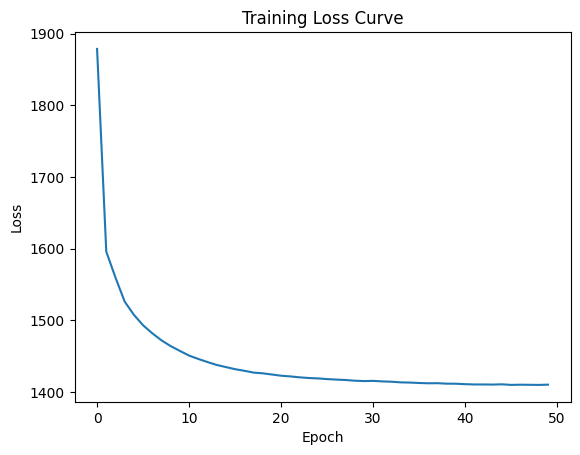

In [13]:
#plotting the loss curve
import matplotlib.pyplot as plt
plt.plot(epoch_loss)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')

In [14]:
model = torch.load("word2vect_tania_sgns.pt",map_location='cpu',weights_only=False)

In [15]:

# 6. Evaluation Function (Cosine Similarity for Inference only)
def find_similar(word, top_n=5):
    if word not in word2idx: return "Not in vocab"
    
    # Use 'in' embeddings for similarity
    weights = model.in_embed.weight.data
    query_vec = weights[word2idx[word]]
    
    # Cosine similarity: (A dot B) / (||A|| * ||B||)
    cos_sim = F.cosine_similarity(query_vec.unsqueeze(0), weights)
    
    scores, indices = torch.topk(cos_sim, top_n + 1)
    for i in range(1, len(indices)): # skip the word itself
        print(f"{idx2word[indices[i].item()]}: {scores[i].item():.4f}")

print("\nResults for 'king':")
find_similar("king")


Results for 'king':
queen: 0.5905
they: 0.5882
sent: 0.5666
where: 0.5467
live: 0.5466


In [16]:
def find_similar_embedding(positive, negative, top_n=5):
    positive_negative = positive + negative
    cos = nn.CosineSimilarity(dim=0, eps=1e-6)

    weights = model.in_embed.weight.data

    for item in positive_negative:
        if item not in word2idx:
            print(f"{item} not in vocabulary")

    query_vec = weights[word2idx[positive[0]]] - weights[word2idx[negative[0]]] + weights[word2idx[positive[1]]]
    
    # Compute cosine similarity with all other words
    similarities = {}
    for word, idx in word2idx.items():
        if word not in positive_negative:
            
            sim = cos(query_vec,weights[idx])
            similarities[word] = sim
    
    # Sort by similarity
    similar_words = sorted(similarities.items(), key=lambda x: x[1], reverse=True)[:top_n]
    
    print(f"\nTop {top_n} words similar to embedding:")
    for word, score in similar_words:
        print(f"{word}: {score:.4f}")

In [17]:
find_similar_embedding(positive = ['king','woman'], negative = ['man'], top_n=5)


Top 5 words similar to embedding:
upon: 0.6329
again: 0.5242
there: 0.5205
curious: 0.5028
gate: 0.5006


In [18]:
find_similar_embedding(positive = ['father','woman'], negative = ['man'], top_n=5)


Top 5 words similar to embedding:
mother: 0.5424
boy: 0.5136
waist: 0.5095
sitting: 0.5016
chair: 0.4888
